# Task 4: Predicting Insurance Claim Amounts
## DevelopersHub Corporation — Data Science & Analytics Internship
---
### Introduction
Medical insurance costs vary greatly from person to person. By analyzing personal data like age, BMI, and smoking habits, we can build a model to predict insurance charges.

### Problem Statement
We need to:
- Load and explore the Medical Cost Personal Dataset
- Visualize how BMI, age, and smoking status affect charges
- Train a **Linear Regression** model to predict insurance charges
- Evaluate model using **MAE** and **RMSE**

### Dataset Description
**Medical Cost Personal Dataset** contains 1,338 records with:
- `age` — Age of the person
- `sex` — Gender (male/female)
- `bmi` — Body Mass Index
- `children` — Number of children
- `smoker` — Smoker or not (yes/no)
- `region` — Residential area (northeast, southeast, southwest, northwest)
- `charges` — **Target:** Medical insurance charges (USD)

**Source:** Loaded directly from GitHub URL — no download required

---
## Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print('Libraries imported successfully!')

Libraries imported successfully!


---
## Step 2: Load Dataset

In [2]:
# Load dataset directly from URL
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)
print('Dataset loaded successfully!')
print('Shape:', df.shape)
df.head()

Dataset loaded successfully!
Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
## Step 3: Data Cleaning & Preparation

In [3]:
# Check missing values
print('Missing Values:')
print(df.isnull().sum())

# Data types
print('\nData Types:')
print(df.dtypes)

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [4]:
# Encode categorical columns
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

# Save smoker column for plotting before get_dummies
smoker_col = df['smoker'].copy()

# One-hot encoding for region
df = pd.get_dummies(df, columns=['region'], drop_first=True)

print('Encoding complete!')
print('sex: male=1, female=0')
print('smoker: yes=1, no=0')
df.head()

Encoding complete!
sex: male=1, female=0
smoker: yes=1, no=0


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


---
## Step 4: Exploratory Data Analysis (EDA)

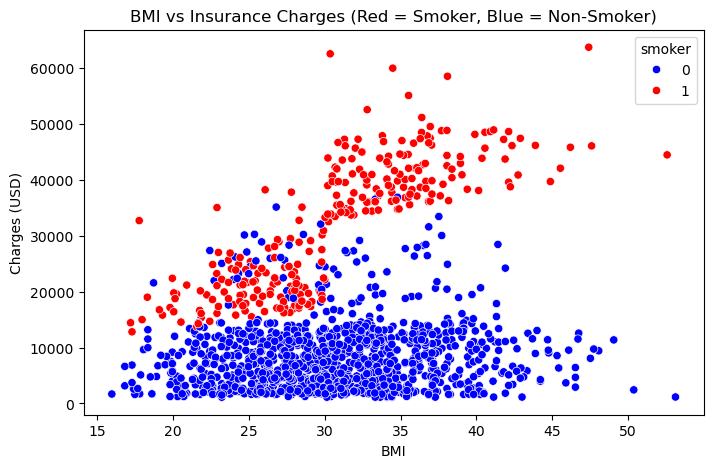

In [5]:
# BMI vs Charges colored by smoking status
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges',
                hue=smoker_col, palette={0: 'blue', 1: 'red'})
plt.title('BMI vs Insurance Charges (Red = Smoker, Blue = Non-Smoker)')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.savefig('task4_bmi_charges.png', dpi=150, bbox_inches='tight')
plt.show()

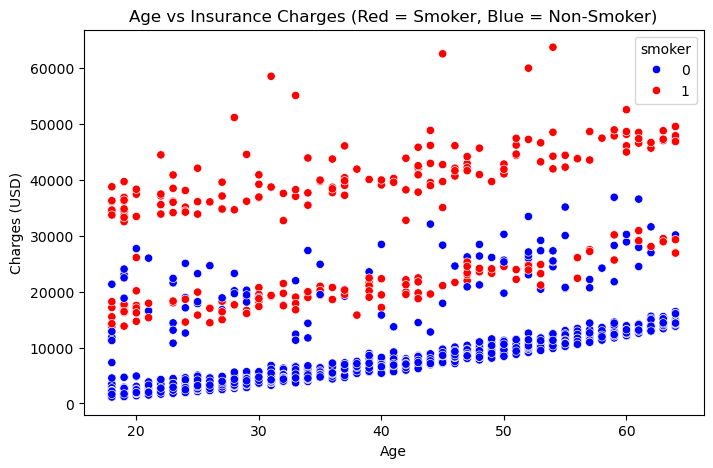

In [6]:
# Age vs Charges
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges',
                hue=smoker_col, palette={0: 'blue', 1: 'red'})
plt.title('Age vs Insurance Charges (Red = Smoker, Blue = Non-Smoker)')
plt.xlabel('Age')
plt.ylabel('Charges (USD)')
plt.savefig('task4_age_charges.png', dpi=150, bbox_inches='tight')
plt.show()

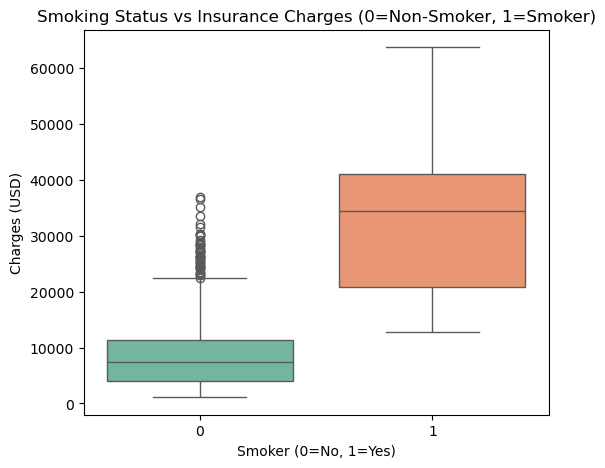

In [7]:
# Smoker vs Charges
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x=smoker_col, y='charges',
            hue=smoker_col, palette='Set2', legend=False)
plt.title('Smoking Status vs Insurance Charges (0=Non-Smoker, 1=Smoker)')
plt.xlabel('Smoker (0=No, 1=Yes)')
plt.ylabel('Charges (USD)')
plt.savefig('task4_smoker_charges.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 5: Model Training — Linear Regression

In [8]:
# Prepare features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (1070, 8)
Testing set size: (268, 8)


In [9]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)
print('Model training complete!')

Model training complete!


---
## Step 6: Model Evaluation

In [10]:
# Predictions
y_pred = model.predict(X_test)

# Calculate MAE and RMSE
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MAE  (Mean Absolute Error): ${mae:.2f}')
print(f'RMSE (Root Mean Squared Error): ${rmse:.2f}')

MAE  (Mean Absolute Error): $4181.19
RMSE (Root Mean Squared Error): $5796.28


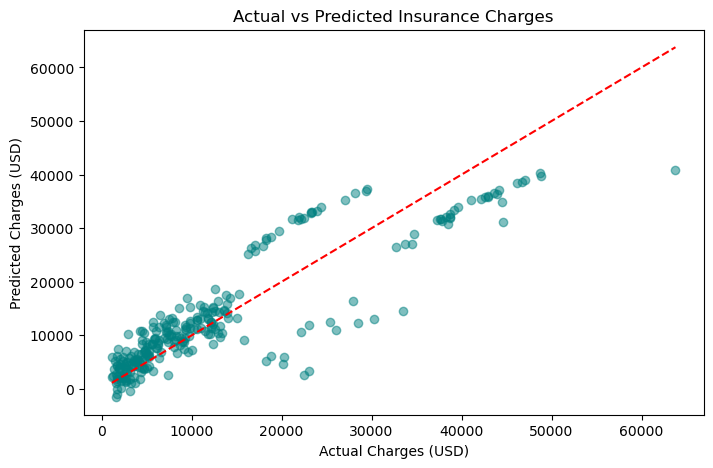

In [11]:
# Actual vs Predicted plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Charges (USD)')
plt.ylabel('Predicted Charges (USD)')
plt.title('Actual vs Predicted Insurance Charges')
plt.savefig('task4_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusion & Key Insights

In [12]:
print('=== KEY INSIGHTS ===')
print(f'1. MAE:  ${mae:.2f} — model predictions are off by this amount on average.')
print(f'2. RMSE: ${rmse:.2f}')
print('3. SMOKING is the STRONGEST predictor of high insurance charges.')
print('4. Smokers pay significantly more than non-smokers.')
print('5. Age positively correlates with charges — older = higher charges.')
print('6. Higher BMI also leads to higher insurance costs.')
print('7. Linear Regression gives a good baseline model for this problem.')

=== KEY INSIGHTS ===
1. MAE:  $4181.19 — model predictions are off by this amount on average.
2. RMSE: $5796.28
3. SMOKING is the STRONGEST predictor of high insurance charges.
4. Smokers pay significantly more than non-smokers.
5. Age positively correlates with charges — older = higher charges.
6. Higher BMI also leads to higher insurance costs.
7. Linear Regression gives a good baseline model for this problem.
